# Bahdanau attention summarizer — raw NumPy port

A from-scratch, hand-derived-backprop port of `bahdanau_torch_rnn.ipynb`, built to
be read class-by-class next to that notebook. Two deliberate simplifications from
the PyTorch version:

- **Vanilla tanh RNN instead of GRU** in both the encoder and decoder (same role,
  much simpler backward pass — no gates to derive).
- **One example at a time**, not batched (matches `DL/lstm_numpy.ipynb`'s style and
  keeps every backward pass a plain sequence of vector/matrix ops instead of
  batch-dimension-aware ones). Since there's no batching, there's also no padding —
  each article/summary is processed at its own true length, so the encoder needs no
  padding mask.

Everything else mirrors the PyTorch notebook on purpose: same data pipeline, same
vocabulary, same `EMBEDDING_SIZE`/`HIDDEN_SIZE`, same Bahdanau attention formula,
same decoder readout (`[rnn_output ; context ; prev-token-embedding]` into the
output projection), same teacher-forcing decay and `<SOS>`-position-excluded loss
that were fixed in the PyTorch notebook.

Each class below exposes `forward`/`backward` like an `nn.Module` would (see
`gpt.ipynb` for the PyTorch-class version of this idea) — but since there's no
autograd, `forward` returns an explicit `cache` and `backward` takes that cache
back in, rather than storing it on `self`. That's required for BPTT: the whole
sequence runs forward first, and backward then replays every step in *reverse*, so
a single `self.cache` slot would only ever hold the last timestep's values.

In [12]:
import os
import random
import time
import numpy as np

random.seed(0)
np.random.seed(0)


## 1. Load BBC News Summary data (identical to `bahdanau_torch_rnn.ipynb`)

In [13]:
base_dir = "../BBC News Summary"
articles_dir = os.path.join(base_dir, "News Articles")
summaries_dir = os.path.join(base_dir, "Summaries")

pairs = []
max_article_len = 40
max_summary_len = 10

categories = os.listdir(articles_dir)
for cat in categories:
    cat_article_dir = os.path.join(articles_dir, cat)
    cat_summary_dir = os.path.join(summaries_dir, cat)
    if not os.path.isdir(cat_article_dir):
        continue
    for fname in sorted(os.listdir(cat_article_dir)):
        if not fname.endswith(".txt"):
            continue
        article_path = os.path.join(cat_article_dir, fname)
        summary_path = os.path.join(cat_summary_dir, fname)
        if not os.path.exists(summary_path):
            continue
        with open(article_path, "r", encoding="latin-1") as f:
            lines = f.read().strip().split("\n")
        article = " ".join(lines[2:]) if len(lines) > 2 else lines[0]
        article_words = article.split()[:max_article_len]
        if len(article_words) < 5:
            continue
        with open(summary_path, "r", encoding="latin-1") as f:
            summary = f.read().strip()
        summary_words = summary.split()[:max_summary_len]
        if len(summary_words) < 3:
            continue
        pairs.append((" ".join(article_words).lower(), " ".join(summary_words).lower()))

print(f"Loaded {len(pairs)} article-summary pairs")

random.shuffle(pairs)
train_split = int(0.7 * len(pairs))
val_split = int(0.85 * len(pairs))
train_pairs = pairs[:train_split]
val_pairs = pairs[train_split:val_split]
test_pairs = pairs[val_split:]
print(f"Training pairs: {len(train_pairs)}, Validation pairs: {len(val_pairs)}, Test pairs: {len(test_pairs)}")


Loaded 2225 article-summary pairs
Training pairs: 1557, Validation pairs: 334, Test pairs: 334


In [14]:
# Build vocabulary (same SPECIAL-token order and logic as the torch notebook)
SPECIAL = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
words = set()
for a, b in pairs:
    words.update(a.split())
    words.update(b.split())
vocab = SPECIAL + sorted(words)
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

def encode(text, add_sos=False, add_eos=False):
    ids = []
    if add_sos:
        ids.append(stoi["<SOS>"])
    for w in text.split():
        ids.append(stoi.get(w, stoi["<UNK>"]))
    if add_eos:
        ids.append(stoi["<EOS>"])
    return np.array(ids, dtype=np.int64)

# no padding/collate needed: every example keeps its own true length
train_data = [(encode(a), encode(b, True, True)) for a, b in train_pairs]
val_data = [(encode(a), encode(b, True, True)) for a, b in val_pairs]
test_data = [(encode(a), encode(b, True, True)) for a, b in test_pairs]


Vocabulary size: 16081


In [15]:
EMBEDDING_SIZE = 128
HIDDEN_SIZE = 256
VOCAB_SIZE = vocab_size
TARGET_LEN = max_summary_len + 2

EPOCHS = 6                    # see note below the training-loop cell for why this is
                               # lower than the torch notebook's 30
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5
MIN_TEACHER_FORCING = 0.5      # teacher forcing decays 1.0 -> this, same as the torch fix
GRAD_CLIP = 5.0

DTYPE = np.float32             # matches PyTorch's default dtype (and is ~2x faster
                                # here than float64, since the output-layer gradient
                                # is memory-bandwidth bound at this vocab size)


## 2. Building blocks

`Embedding`, `Linear`, and `RNNCell` are small reusable layers, the NumPy analogues
of `nn.Embedding`, `nn.Linear`, and `nn.RNN` (used here in place of `nn.GRU`, per
the "simplicity" request — a vanilla tanh cell has one gate instead of three, so its
backward pass is a single line instead of four).

In [16]:
def xavier(shape, dtype=DTYPE):
    fan_out = shape[0]
    fan_in = shape[1] if len(shape) > 1 else shape[0]
    limit = np.sqrt(6.0 / (fan_in + fan_out))
    return np.random.uniform(-limit, limit, size=shape).astype(dtype)


def softmax(x):
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.sum(e)


In [17]:
class Embedding:
    """NumPy analogue of nn.Embedding: a (vocab, emb) lookup table."""

    def __init__(self, vocab_size, emb_dim, dtype=DTYPE):
        self.W = xavier((vocab_size, emb_dim), dtype)
        self.dW = np.zeros_like(self.W)

    def forward(self, idx):
        return self.W[idx]

    def backward(self, idx, dvec):
        self.dW[idx] += dvec

    def zero_grad(self):
        self.dW.fill(0)

    def parameters(self):
        return [(self.W, self.dW)]

    def named_parameters(self, prefix=""):
        return [(prefix + "W", self.W)]


In [18]:
class Linear:
    """NumPy analogue of nn.Linear: out = W @ x + b."""

    def __init__(self, in_dim, out_dim, dtype=DTYPE):
        self.W = xavier((out_dim, in_dim), dtype)
        self.b = np.zeros(out_dim, dtype=dtype)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

    def forward(self, x):
        out = self.W @ x + self.b
        return out, x  # cache = input x

    def backward(self, dout, cache):
        x = cache
        self.dW += np.outer(dout, x)
        self.db += dout
        return self.W.T @ dout

    def zero_grad(self):
        self.dW.fill(0)
        self.db.fill(0)

    def parameters(self):
        return [(self.W, self.dW), (self.b, self.db)]

    def named_parameters(self, prefix=""):
        return [(prefix + "W", self.W), (prefix + "b", self.b)]


In [19]:
class RNNCell:
    """Vanilla tanh RNN cell (used in place of nn.GRU):
    h_t = tanh(Wxh @ x_t + Whh @ h_{t-1} + bh)
    """

    def __init__(self, input_size, hidden_size, dtype=DTYPE):
        self.Wxh = xavier((hidden_size, input_size), dtype)
        self.Whh = xavier((hidden_size, hidden_size), dtype)
        self.bh = np.zeros(hidden_size, dtype=dtype)
        self.dWxh = np.zeros_like(self.Wxh)
        self.dWhh = np.zeros_like(self.Whh)
        self.dbh = np.zeros_like(self.bh)

    def step(self, x_t, h_prev):
        z = self.Wxh @ x_t + self.Whh @ h_prev + self.bh
        h_t = np.tanh(z)
        return h_t, (x_t, h_prev, h_t)

    def step_backward(self, dh_t, cache):
        x_t, h_prev, h_t = cache
        dz = dh_t * (1 - h_t ** 2)                 # tanh backward
        self.dWxh += np.outer(dz, x_t)
        self.dWhh += np.outer(dz, h_prev)
        self.dbh += dz
        dx_t = self.Wxh.T @ dz
        dh_prev = self.Whh.T @ dz
        return dx_t, dh_prev

    def zero_grad(self):
        self.dWxh.fill(0)
        self.dWhh.fill(0)
        self.dbh.fill(0)

    def parameters(self):
        return [(self.Wxh, self.dWxh), (self.Whh, self.dWhh), (self.bh, self.dbh)]

    def named_parameters(self, prefix=""):
        return [(prefix + "Wxh", self.Wxh), (prefix + "Whh", self.Whh), (prefix + "bh", self.bh)]


## 3. Bahdanau attention

Mirrors `BahdanauAttention(nn.Module)` exactly: `energy = tanh(W_s(query) +
W_h(encoder_outputs))`, `scores = v(energy)`, softmax over the source positions,
weighted sum for the context vector. `W_s`/`W_h`/`v` are named the same as the
torch version's `nn.Linear` sub-modules (including their biases) so the two are
easy to compare line by line.

The backward pass is the one part with no PyTorch equivalent to read off — gradient
reaches the encoder states `H` through **two separate paths**: directly through the
context weighted-sum, and through the attention *scores* (since `H` is also used as
the attention "key"). Both are accumulated into the same `dH_enc`.

In [20]:
class BahdanauAttention:
    def __init__(self, hidden_size, dtype=DTYPE):
        self.W_s = xavier((hidden_size, hidden_size), dtype)
        self.b_s = np.zeros(hidden_size, dtype=dtype)
        self.W_h = xavier((hidden_size, hidden_size), dtype)
        self.b_h = np.zeros(hidden_size, dtype=dtype)
        self.v = xavier((1, hidden_size), dtype)
        self.bv = np.zeros(1, dtype=dtype)

        self.dW_s = np.zeros_like(self.W_s)
        self.db_s = np.zeros_like(self.b_s)
        self.dW_h = np.zeros_like(self.W_h)
        self.db_h = np.zeros_like(self.b_h)
        self.dv = np.zeros_like(self.v)
        self.dbv = np.zeros_like(self.bv)

    def forward(self, decoder_hidden, encoder_outputs):
        # U[i] = tanh(W_s @ decoder_hidden + b_s + W_h @ encoder_outputs[i] + b_h)
        query_proj = self.W_s @ decoder_hidden + self.b_s          # (H,)
        keys_proj = encoder_outputs @ self.W_h.T + self.b_h        # (T_x, H)
        U = np.tanh(keys_proj + query_proj)                        # (T_x, H)
        scores = U @ self.v[0] + self.bv[0]                        # (T_x,)
        alpha = softmax(scores)                                    # (T_x,)
        context = alpha @ encoder_outputs                          # (H,)
        cache = (U, alpha, encoder_outputs, decoder_hidden)
        return context, alpha, cache

    def backward(self, dcontext, cache):
        U, alpha, H_enc, decoder_hidden = cache

        dH_enc = np.outer(alpha, dcontext)                         # context path
        dalpha = H_enc @ dcontext
        dscores = alpha * (dalpha - np.sum(alpha * dalpha))        # softmax backward

        self.dv[0] += dscores @ U
        self.dbv[0] += np.sum(dscores)
        dU = np.outer(dscores, self.v[0])
        dz = dU * (1 - U ** 2)                                     # tanh backward

        dz_sum = dz.sum(axis=0)
        self.dW_s += np.outer(dz_sum, decoder_hidden)
        self.db_s += dz_sum
        self.dW_h += dz.T @ H_enc
        self.db_h += dz_sum

        ddecoder_hidden = self.W_s.T @ dz_sum
        dH_enc += dz @ self.W_h                                    # attention-key path
        return ddecoder_hidden, dH_enc

    def zero_grad(self):
        for g in (self.dW_s, self.db_s, self.dW_h, self.db_h, self.dv, self.dbv):
            g.fill(0)

    def parameters(self):
        return [(self.W_s, self.dW_s), (self.b_s, self.db_s),
                (self.W_h, self.dW_h), (self.b_h, self.db_h),
                (self.v, self.dv), (self.bv, self.dbv)]

    def named_parameters(self, prefix=""):
        return [(prefix + "W_s", self.W_s), (prefix + "b_s", self.b_s),
                (prefix + "W_h", self.W_h), (prefix + "b_h", self.b_h),
                (prefix + "v", self.v), (prefix + "bv", self.bv)]


## 4. Encoder

Mirrors `Encoder(nn.Module)`, minus dropout and `pack_padded_sequence` — with no
batching there's no padding, so every article is just run through the RNN at its
own true length. It keeps every hidden state `H` (not just the last), since
attention needs to look back at all of them.

In [21]:
class Encoder:
    def __init__(self, embedding, emb_dim, hidden_size, dtype=DTYPE):
        self.embedding = embedding
        self.rnn_cell = RNNCell(emb_dim, hidden_size, dtype)
        self.hidden_size = hidden_size
        self.dtype = dtype

    def forward(self, x_ids):
        T = len(x_ids)
        H = np.zeros((T, self.hidden_size), dtype=self.dtype)
        caches = []
        h_prev = np.zeros(self.hidden_size, dtype=self.dtype)
        for t in range(T):
            x_t = self.embedding.forward(x_ids[t])
            h_t, rnn_cache = self.rnn_cell.step(x_t, h_prev)
            H[t] = h_t
            caches.append((x_ids[t], rnn_cache))
            h_prev = h_t
        return H, caches

    def backward(self, dH, dh_last, caches):
        """dH: gradient into every H[t] from attention. dh_last: gradient into
        H[-1] from being used as the decoder's initial hidden state (the bridge)."""
        dh_next = dh_last
        for t in reversed(range(len(caches))):
            x_id, rnn_cache = caches[t]
            dh_total = dH[t] + dh_next
            dx_t, dh_prev = self.rnn_cell.step_backward(dh_total, rnn_cache)
            self.embedding.backward(x_id, dx_t)
            dh_next = dh_prev

    def zero_grad(self):
        self.rnn_cell.zero_grad()

    def parameters(self):
        return self.rnn_cell.parameters()

    def named_parameters(self, prefix=""):
        return self.rnn_cell.named_parameters(prefix + "rnn_cell.")


## 5. Decoder

Mirrors `Decoder(nn.Module)`: `forward_step` attends over the encoder states, runs
one RNN step over `[prev-token-embedding ; context]`, then predicts from
`[rnn_output ; context ; prev-token-embedding]` — the same three-way concat as
`fc_out` in the torch version (not just the RNN output alone).

In [22]:
class Decoder:
    def __init__(self, embedding, emb_dim, hidden_size, vocab_size, dtype=DTYPE):
        self.embedding = embedding
        self.attention = BahdanauAttention(hidden_size, dtype)
        self.rnn_cell = RNNCell(emb_dim + hidden_size, hidden_size, dtype)
        self.fc_out = Linear(hidden_size * 2 + emb_dim, vocab_size, dtype)
        self.hidden_size = hidden_size
        self.emb_dim = emb_dim

    def step(self, input_token_id, hidden, encoder_outputs):
        embedded = self.embedding.forward(input_token_id)
        context, alpha, attn_cache = self.attention.forward(hidden, encoder_outputs)
        rnn_input = np.concatenate([embedded, context])
        hidden_new, rnn_cache = self.rnn_cell.step(rnn_input, hidden)
        pred_input = np.concatenate([hidden_new, context, embedded])
        logits, fc_cache = self.fc_out.forward(pred_input)
        cache = (input_token_id, attn_cache, rnn_cache, fc_cache)
        return logits, hidden_new, alpha, cache

    def step_backward(self, dlogits, dhidden_next, cache):
        input_token_id, attn_cache, rnn_cache, fc_cache = cache
        H, E = self.hidden_size, self.emb_dim

        dpred_input = self.fc_out.backward(dlogits, fc_cache)
        dhidden_new = dpred_input[:H] + dhidden_next
        dcontext = dpred_input[H:2 * H]
        dembedded = dpred_input[2 * H:2 * H + E].copy()

        drnn_input, dhidden_prev = self.rnn_cell.step_backward(dhidden_new, rnn_cache)
        dembedded += drnn_input[:E]
        dcontext = dcontext + drnn_input[E:]

        ddecoder_hidden, dH_enc = self.attention.backward(dcontext, attn_cache)
        dhidden_prev = dhidden_prev + ddecoder_hidden

        self.embedding.backward(input_token_id, dembedded)
        return dhidden_prev, dH_enc

    def zero_grad(self):
        self.attention.zero_grad()
        self.rnn_cell.zero_grad()
        self.fc_out.zero_grad()

    def parameters(self):
        return self.attention.parameters() + self.rnn_cell.parameters() + self.fc_out.parameters()

    def named_parameters(self, prefix=""):
        params = []
        params += self.attention.named_parameters(prefix + "attention.")
        params += self.rnn_cell.named_parameters(prefix + "rnn_cell.")
        params += self.fc_out.named_parameters(prefix + "fc_out.")
        return params


## 6. Seq2Seq

Mirrors `Seq2Seq(nn.Module)`: `forward` runs the encoder once, then unrolls the
decoder with **scheduled sampling** — feeding the true previous token with
probability `teacher_forcing_ratio`, else the model's own greedy prediction, same
as the fixed `Decoder.forward` in the torch notebook. The loss loop starts at `t=0`
predicting `tgt_ids[1]`, so — like the fixed torch version — the `<SOS>` position is
never scored (there's nothing to predict there, it's the given first input).

`greedy_decode` is the autoregressive inference path, identical in spirit to
`Seq2Seq.greedy_decode` in the torch notebook.

In [23]:
class Seq2Seq:
    def __init__(self, vocab_size, emb_dim, hidden_size, dtype=DTYPE):
        self.embedding = Embedding(vocab_size, emb_dim, dtype)  # shared, like torch's shared_embedding
        self.encoder = Encoder(self.embedding, emb_dim, hidden_size, dtype)
        self.decoder = Decoder(self.embedding, emb_dim, hidden_size, vocab_size, dtype)

    def forward(self, src_ids, tgt_ids, teacher_forcing_ratio=1.0):
        H, enc_caches = self.encoder.forward(src_ids)
        hidden = H[-1]                              # bridge: decoder starts from encoder's last state
        loss = 0.0
        dec_caches = []
        input_token = int(tgt_ids[0])                # always start from the true <SOS>
        for t in range(len(tgt_ids) - 1):
            target_id = int(tgt_ids[t + 1])
            logits, hidden, alpha, cache = self.decoder.step(input_token, hidden, H)
            probs = softmax(logits)
            loss += -np.log(probs[target_id] + 1e-9)
            dec_caches.append((cache, probs, target_id))

            use_teacher_forcing = random.random() < teacher_forcing_ratio
            input_token = int(tgt_ids[t + 1]) if use_teacher_forcing else int(np.argmax(logits))
        loss /= max(1, len(tgt_ids) - 1)
        return loss, H, enc_caches, dec_caches

    def backward(self, H, enc_caches, dec_caches):
        dH = np.zeros_like(H)
        dhidden_next = np.zeros(H.shape[1], dtype=H.dtype)
        n = len(dec_caches)
        for t in reversed(range(n)):
            cache, probs, target_id = dec_caches[t]
            dlogits = probs.copy()
            dlogits[target_id] -= 1.0
            dlogits /= n
            dhidden_prev, dH_t = self.decoder.step_backward(dlogits, dhidden_next, cache)
            dH += dH_t
            dhidden_next = dhidden_prev
        self.encoder.backward(dH, dhidden_next, enc_caches)

    def greedy_decode(self, src_ids, sos_id, eos_id, max_len):
        H, _ = self.encoder.forward(src_ids)
        hidden = H[-1]
        token = sos_id
        tokens = []
        for _ in range(max_len):
            logits, hidden, alpha, _ = self.decoder.step(token, hidden, H)
            token = int(np.argmax(logits))
            if token == eos_id:
                break
            tokens.append(token)
        return tokens

    def zero_grad(self):
        self.embedding.zero_grad()
        self.encoder.zero_grad()
        self.decoder.zero_grad()

    def parameters(self):
        return self.embedding.parameters() + self.encoder.parameters() + self.decoder.parameters()

    def named_parameters(self):
        params = []
        params += self.embedding.named_parameters("embedding.")
        params += self.encoder.named_parameters("encoder.")
        params += self.decoder.named_parameters("decoder.")
        return params

    def state_dict(self):
        return {name: arr.copy() for name, arr in self.named_parameters()}

    def load_state_dict(self, state_dict):
        own_params = dict(self.named_parameters())
        assert set(own_params) == set(state_dict), "checkpoint parameter names do not match model"
        for name, arr in state_dict.items():
            own_params[name][...] = arr


## 7. Optimizer

A from-scratch Adam (matches `optim.Adam(model.parameters(), lr=0.001,
weight_decay=1e-5)` from the torch notebook, including L2 weight decay folded into
the gradient before the moment updates, the same way `torch.optim.Adam` does it)
plus global-norm gradient clipping per parameter array — vanilla tanh RNNs need
this more than GRUs do, since there's no gating to help gradients survive many
timesteps.

In [24]:
class Adam:
    def __init__(self, parameters, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.weight_decay = weight_decay
        self.m = [np.zeros_like(p) for p, g in parameters]
        self.v = [np.zeros_like(p) for p, g in parameters]
        self.t = 0

    def step(self, parameters):
        self.t += 1
        for i, (p, g) in enumerate(parameters):
            g = g + self.weight_decay * p
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g ** 2)
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)
            p -= (self.lr * m_hat / (np.sqrt(v_hat) + self.eps)).astype(p.dtype)


def clip_grads(parameters, max_norm=GRAD_CLIP):
    for p, g in parameters:
        norm = np.linalg.norm(g)
        if norm > max_norm:
            g *= max_norm / (norm + 1e-9)


## 8. Gradient check

Verify `Decoder.step_backward` / `Encoder.backward` against finite differences
**before** trusting them to train the real model. This uses a tiny throwaway model
(small vocab/hidden size, float64) rather than the real 16081-word/256-hidden one —
float32 finite differences are too imprecise to give a clean signal, and the real
model's output layer is too expensive to call ~60 extra times just for a sanity
check. The class logic being checked is identical either way; only the sizes and
dtype differ.

In [25]:
def gradient_check():
    rng_state = random.getstate()
    np_state = np.random.get_state()
    try:
        random.seed(1)
        np.random.seed(1)
        tiny_vocab, tiny_emb, tiny_hidden = 30, 6, 8
        check_model = Seq2Seq(tiny_vocab, tiny_emb, tiny_hidden, dtype=np.float64)
        src_ids = np.random.randint(0, tiny_vocab, size=5)
        tgt_ids = np.array([1, 4, 7, 2], dtype=np.int64)  # arbitrary <SOS> ... <EOS>-shaped sequence

        loss0, H, enc_caches, dec_caches = check_model.forward(src_ids, tgt_ids, teacher_forcing_ratio=1.0)
        check_model.zero_grad()
        check_model.backward(H, enc_caches, dec_caches)
        analytic_params = check_model.parameters()

        epsilon = 1e-5
        rng = np.random.RandomState(0)
        worst_rel_err = 0.0
        print(f"{'param shape':16s} {'index':16s} {'analytic':>12s} {'numeric':>12s} {'rel err':>10s}")
        for p, g in analytic_params:
            flat_idx = tuple(rng.randint(0, s) for s in p.shape)
            orig = p[flat_idx]

            p[flat_idx] = orig + epsilon
            loss_plus, _, _, _ = check_model.forward(src_ids, tgt_ids, teacher_forcing_ratio=1.0)
            p[flat_idx] = orig - epsilon
            loss_minus, _, _, _ = check_model.forward(src_ids, tgt_ids, teacher_forcing_ratio=1.0)
            p[flat_idx] = orig

            numeric = (loss_plus - loss_minus) / (2 * epsilon)
            analytic = g[flat_idx]
            rel_err = abs(analytic - numeric) / max(1e-8, abs(analytic) + abs(numeric))
            worst_rel_err = max(worst_rel_err, rel_err)
            print(f"{str(p.shape):16s} {str(flat_idx):16s} {analytic:12.6f} {numeric:12.6f} {rel_err:10.2e}")

        print(f"\nworst relative error across all parameter arrays: {worst_rel_err:.2e}")
        assert worst_rel_err < 1e-3, "gradient check failed - backward pass does not match finite differences"
        print("Gradient check passed.")
    finally:
        random.setstate(rng_state)
        np.random.set_state(np_state)


gradient_check()


param shape      index                analytic      numeric    rel err
(30, 6)          (12, 5)              0.000000     0.000000   0.00e+00
(8, 6)           (0, 3)              -0.017641    -0.017641   8.19e-09
(8, 8)           (3, 3)               0.016431     0.016431   1.34e-08
(8,)             (7,)                 0.038701     0.038701   2.65e-08
(8, 8)           (1, 3)               0.001317     0.001317   1.57e-08
(8,)             (5,)                 0.007635     0.007635   1.28e-08
(8, 8)           (2, 4)              -0.007259    -0.007259   1.24e-08
(8,)             (7,)                -0.002283    -0.002283   8.76e-09
(1, 8)           (0, 6)               0.015657     0.015657   1.34e-08
(1,)             (0,)                 0.000000     0.000000   6.61e-10
(8, 14)          (0, 8)              -0.007840    -0.007840   1.60e-08
(8, 8)           (4, 2)               0.024427     0.024427   2.44e-08
(8,)             (1,)                 0.102083     0.102083   1.34e-08
(30, 2

## 8.5. Quick sanity check: overfit a tiny subset

Before committing to the full ~80-90 minute run below, check that the whole pipeline
(data -> encoder -> attention -> decoder -> hand-derived backprop -> Adam) is actually
*capable* of learning anything at all. Take a small subset (100 pairs), build a
vocabulary from just those words, and use smaller `EMBEDDING_SIZE`/`HIDDEN_SIZE` for
this experiment only - and train with **no train/val split and no early stopping**,
just a fixed 100 epochs, checking whether the model can reproduce (memorize) the
summaries it was trained on.

Two things made the first version of this too slow (it was on pace for ~80+ min, no
faster than the full run):
1. **BLAS thread oversubscription.** OpenBLAS defaults to spawning up to 12 threads
   per matmul on this machine. For the tiny per-timestep matrices here (a few hundred
   floats), thread spawn/sync overhead swamps the actual math - single-threaded BLAS
   is faster. `threadpoolctl.threadpool_limits(1)` fixes this for just this cell,
   without touching the full run's threading below (its `fc_out` matmul is much
   bigger and can actually benefit from multiple threads).
2. **Vocab/dims not shrunk enough.** Subsetting rows alone still left `fc_out` sized
   by the subset's vocab (~2700 words) at the full `HIDDEN_SIZE=256`. Here both the
   sample count and `EMBEDDING_SIZE`/`HIDDEN_SIZE` are reduced, verified by direct
   timing to finish 100 epochs in well under 5 minutes.

- If it can't even reproduce summaries for data it was trained directly on, that's a
  real implementation bug, not a data-scarcity issue.
- If it can, the full-dataset run's weak generations are "1557 examples isn't enough
  data / not enough epochs / not enough capacity," not broken code.

This uses a fresh, separate model instance (`overfit_model`) - it does not touch
`model`, `train_data`, `val_data`, or `test_data` used by the full run below.

In [26]:
# --- Overfit sanity check: small subset, no val/early stopping, tuned to run fast ---
OVERFIT_N = 100                # total rows, no train/val/test split
OVERFIT_EPOCHS = 100           # fixed count, no early stopping - we WANT to overfit here
OVERFIT_EMBEDDING_SIZE = 64    # smaller than the real EMBEDDING_SIZE=128, just for this check
OVERFIT_HIDDEN_SIZE = 128      # smaller than the real HIDDEN_SIZE=256, just for this check

random.seed(0)
overfit_pairs = random.sample(pairs, OVERFIT_N)

# Vocab built only from this subset - this (plus the smaller dims above) is what
# makes it fast: fc_out shrinks from vocab_size x (2*HIDDEN_SIZE+EMBEDDING_SIZE) down
# to a small fraction of that.
overfit_words = set()
for a, b in overfit_pairs:
    overfit_words.update(a.split())
    overfit_words.update(b.split())
overfit_vocab = SPECIAL + sorted(overfit_words)
overfit_stoi = {w: i for i, w in enumerate(overfit_vocab)}
overfit_itos = {i: w for w, i in overfit_stoi.items()}
overfit_vocab_size = len(overfit_vocab)


def overfit_encode(text, add_sos=False, add_eos=False):
    ids = []
    if add_sos:
        ids.append(overfit_stoi["<SOS>"])
    for w in text.split():
        ids.append(overfit_stoi.get(w, overfit_stoi["<UNK>"]))
    if add_eos:
        ids.append(overfit_stoi["<EOS>"])
    return np.array(ids, dtype=np.int64)


overfit_data = [(overfit_encode(a), overfit_encode(b, True, True)) for a, b in overfit_pairs]

full_fc_out = vocab_size * (2 * HIDDEN_SIZE + EMBEDDING_SIZE)
overfit_fc_out = overfit_vocab_size * (2 * OVERFIT_HIDDEN_SIZE + OVERFIT_EMBEDDING_SIZE)
print(f"Overfit subset: {len(overfit_data)} pairs, vocab size: {overfit_vocab_size} (vs {vocab_size} full)")
print(f"fc_out shrinks from {full_fc_out:,} elements to {overfit_fc_out:,} elements "
      f"({full_fc_out / overfit_fc_out:.0f}x smaller)")


Overfit subset: 100 pairs, vocab size: 2050 (vs 16081 full)
fc_out shrinks from 10,291,840 elements to 656,000 elements (16x smaller)


In [27]:
import threadpoolctl

overfit_model = Seq2Seq(overfit_vocab_size, OVERFIT_EMBEDDING_SIZE, OVERFIT_HIDDEN_SIZE, dtype=DTYPE)
overfit_optimizer = Adam(overfit_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

start = time.time()
with threadpoolctl.threadpool_limits(limits=1, user_api="blas"):
    # Single-threaded BLAS: these matmuls are tiny, so thread spawn/sync overhead
    # would otherwise dominate (see markdown note above) - this alone was the main
    # fix for the "still taking too much time" slowdown.
    for epoch in range(1, OVERFIT_EPOCHS + 1):
        random.shuffle(overfit_data)
        total_loss = 0.0
        for src_ids, tgt_ids in overfit_data:
            # No teacher-forcing decay here - we WANT this to overfit as easily as
            # possible, so stay fully teacher-forced for all 100 epochs.
            loss, H, enc_caches, dec_caches = overfit_model.forward(src_ids, tgt_ids, teacher_forcing_ratio=1.0)
            overfit_model.zero_grad()
            overfit_model.backward(H, enc_caches, dec_caches)
            params = overfit_model.parameters()
            clip_grads(params)
            overfit_optimizer.step(params)
            total_loss += loss

        train_loss = total_loss / len(overfit_data)
        if epoch == 1 or epoch % 10 == 0 or epoch == OVERFIT_EPOCHS:
            elapsed = time.time() - start
            print(f"Epoch {epoch}/{OVERFIT_EPOCHS}  train loss: {train_loss:.4f}  elapsed: {elapsed:.1f}s")

print(f"\nDone in {time.time() - start:.1f}s")


Epoch 1/100  train loss: 6.8058  elapsed: 2.2s
Epoch 10/100  train loss: 2.6748  elapsed: 19.5s
Epoch 20/100  train loss: 0.1602  elapsed: 39.5s
Epoch 30/100  train loss: 0.0335  elapsed: 58.0s
Epoch 40/100  train loss: 0.0147  elapsed: 77.0s
Epoch 50/100  train loss: 0.0551  elapsed: 96.3s
Epoch 60/100  train loss: 0.0066  elapsed: 115.3s
Epoch 70/100  train loss: 0.0042  elapsed: 134.1s
Epoch 80/100  train loss: 0.0031  elapsed: 153.5s
Epoch 90/100  train loss: 0.0026  elapsed: 172.4s
Epoch 100/100  train loss: 0.0023  elapsed: 191.2s

Done in 191.2s


In [ ]:
def overfit_summarize_ids(src_ids):
    tokens = overfit_model.greedy_decode(src_ids, overfit_stoi["<SOS>"], overfit_stoi["<EOS>"], max_len=TARGET_LEN)
    return " ".join(overfit_itos[i] for i in tokens
                     if i not in (overfit_stoi["<SOS>"], overfit_stoi["<EOS>"], overfit_stoi["<PAD>"]))


def overfit_ids_to_text(ids):
    return " ".join(overfit_itos[int(i)] for i in ids
                     if int(i) not in (overfit_stoi["<SOS>"], overfit_stoi["<EOS>"], overfit_stoi["<PAD>"]))


exact_matches = 0
sample = overfit_data[:15]
for src_ids, tgt_ids in sample:
    predicted = overfit_summarize_ids(src_ids)
    actual = overfit_ids_to_text(tgt_ids)
    if predicted == actual:
        exact_matches += 1
    print(f"Article: {overfit_ids_to_text(src_ids)}")
    print(f"Actual Summary: {actual}")
    print(f"Predicted: {predicted}")
    print("=" * 50)

print(f"\nExact match on shown sample: {exact_matches}/{len(sample)}")


Article: surfers outside the us have been unable to visit the official re-election site of president george w bush. the blocking of browsers sited outside the us began in the early hours of monday morning. since then people outside the us
Actual Summary: since then people outside the us trying to browse the
Predicted: since then people outside the us trying to browse the
Article: eurosceptic party ukip have suspended a candidate for allegedly suggesting the criminally insane should be killed. john houston, 54, was due to stand in the east kilbride seat in lanarkshire at the next election. but he was suspended after his
Actual Summary: peter nielson, who is ukip scotland chairman, said he had
Predicted: peter nielson, who is ukip scotland chairman, said he had
Article: labour's leadership put on a show of unity at a campaign poster launch after mps criticised tony blair and gordon brown over reports of their rift. mr brown was joined at the launch by john prescott and alan milburn, the


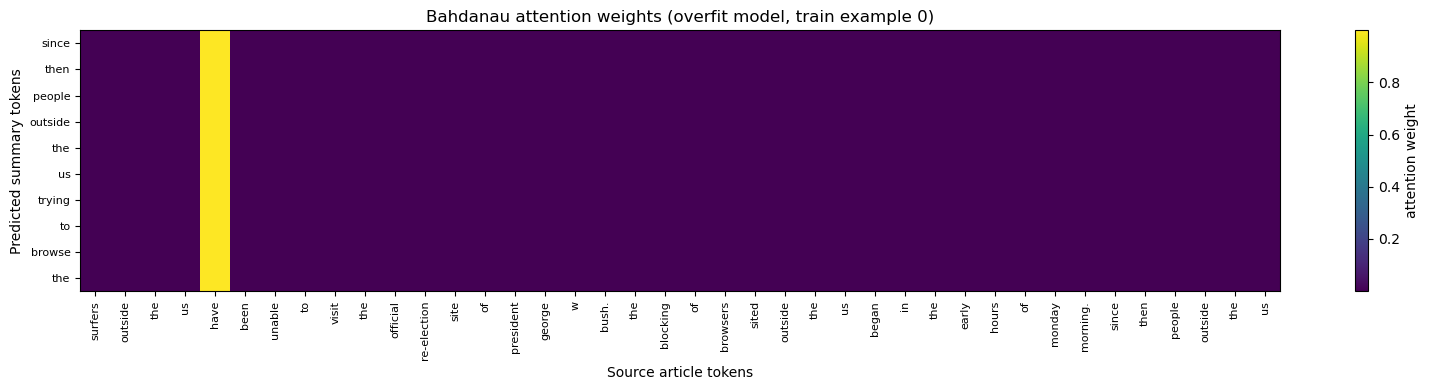

Predicted: since then people outside the us trying to browse the
Actual:    since then people outside the us trying to browse the


In [29]:
import matplotlib.pyplot as plt


def decode_with_attention(model, src_ids, sos_id, eos_id, max_len):
    """Same as Seq2Seq.greedy_decode, but also collects the attention weights
    (alpha) at every decoder step, for visualization."""
    H, _ = model.encoder.forward(src_ids)
    hidden = H[-1]
    token = sos_id
    tokens = []
    alphas = []
    for _ in range(max_len):
        logits, hidden, alpha, _ = model.decoder.step(token, hidden, H)
        token = int(np.argmax(logits))
        if token == eos_id:
            break
        tokens.append(token)
        alphas.append(alpha)
    return tokens, np.array(alphas)  # (tgt_len, src_len)


src_ids, tgt_ids = overfit_data[0]
pred_tokens, attn_matrix = decode_with_attention(
    overfit_model, src_ids, overfit_stoi["<SOS>"], overfit_stoi["<EOS>"], max_len=TARGET_LEN
)
src_words = [overfit_itos[int(i)] for i in src_ids]
pred_words = [overfit_itos[t] for t in pred_tokens]

fig, ax = plt.subplots(figsize=(max(8, len(src_words) * 0.4), max(4, len(pred_words) * 0.4)))
im = ax.imshow(attn_matrix, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(src_words)))
ax.set_xticklabels(src_words, rotation=90, fontsize=8)
ax.set_yticks(range(len(pred_words)))
ax.set_yticklabels(pred_words, fontsize=8)
ax.set_xlabel("Source article tokens")
ax.set_ylabel("Predicted summary tokens")
ax.set_title("Bahdanau attention weights (overfit model, train example 0)")
fig.colorbar(im, ax=ax, label="attention weight")
fig.tight_layout()
plt.show()

print(f"Predicted: {' '.join(pred_words)}")
print(f"Actual:    {overfit_ids_to_text(tgt_ids)}")


In [30]:
import json

OVERFIT_CHECKPOINT_DIR = "DL/checkpoints"
os.makedirs(OVERFIT_CHECKPOINT_DIR, exist_ok=True)
OVERFIT_WEIGHTS_PATH = os.path.join(OVERFIT_CHECKPOINT_DIR, "bahdanau_numpy_overfit.npz")
OVERFIT_META_PATH = os.path.join(OVERFIT_CHECKPOINT_DIR, "bahdanau_numpy_overfit_meta.json")

np.savez(OVERFIT_WEIGHTS_PATH, **overfit_model.state_dict())
with open(OVERFIT_META_PATH, "w") as f:
    json.dump({
        "stoi": overfit_stoi,
        "EMBEDDING_SIZE": OVERFIT_EMBEDDING_SIZE,
        "HIDDEN_SIZE": OVERFIT_HIDDEN_SIZE,
        "VOCAB_SIZE": overfit_vocab_size,
        "TARGET_LEN": TARGET_LEN,
    }, f)

print(f"Saved overfit model weights to {OVERFIT_WEIGHTS_PATH}")
print(f"Saved overfit vocab/config to {OVERFIT_META_PATH}")


Saved overfit model weights to DL/checkpoints/bahdanau_numpy_overfit.npz
Saved overfit vocab/config to DL/checkpoints/bahdanau_numpy_overfit_meta.json


## 9. Model, evaluation, and training loop

Instantiate the real model at the torch notebook's actual sizes
(`EMBEDDING_SIZE=128`, `HIDDEN_SIZE=256`, full 16081-word vocabulary).

In [31]:
model = Seq2Seq(VOCAB_SIZE, EMBEDDING_SIZE, HIDDEN_SIZE, dtype=DTYPE)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
print(f"Total parameter arrays: {len(model.parameters())}")
print(f"Total parameters: {sum(p.size for p, g in model.parameters()):,}")


Total parameter arrays: 15
Total parameters: 12,760,786


In [32]:
def evaluate(data, teacher_forcing_ratio=1.0):
    total_loss = 0.0
    for src_ids, tgt_ids in data:
        loss, _, _, _ = model.forward(src_ids, tgt_ids, teacher_forcing_ratio=teacher_forcing_ratio)
        total_loss += loss
    return total_loss / len(data)


## Full dataset run -> code below

In [34]:
# start = time.time()
# for epoch in range(1, EPOCHS + 1):
#     random.shuffle(train_data)
#     total_loss = 0.0
#     # decay teacher forcing linearly from 1.0 to MIN_TEACHER_FORCING, same as the torch fix
#     teacher_forcing_ratio = 1.0 - (1.0 - MIN_TEACHER_FORCING) * ((epoch - 1) / max(1, EPOCHS - 1))
#     for src_ids, tgt_ids in train_data:
#         loss, H, enc_caches, dec_caches = model.forward(src_ids, tgt_ids, teacher_forcing_ratio)
#         model.zero_grad()
#         model.backward(H, enc_caches, dec_caches)
#         params = model.parameters()
#         clip_grads(params)
#         optimizer.step(params)
#         total_loss += loss

#     train_loss = total_loss / len(train_data)
#     val_loss = evaluate(val_data)  # teacher_forcing_ratio=1.0, matches the torch evaluate()
#     elapsed_min = (time.time() - start) / 60
#     print(f"Epoch {epoch}/{EPOCHS}  train loss: {train_loss:.4f}  val loss: {val_loss:.4f}  "
#           f"TF ratio: {teacher_forcing_ratio:.2f}  elapsed: {elapsed_min:.1f} min")


## 11. Save / load the trained model

In [35]:
# import json

# CHECKPOINT_DIR = "DL/checkpoints"
# os.makedirs(CHECKPOINT_DIR, exist_ok=True)
# WEIGHTS_PATH = os.path.join(CHECKPOINT_DIR, "bahdanau_numpy.npz")
# META_PATH = os.path.join(CHECKPOINT_DIR, "bahdanau_numpy_meta.json")

# np.savez(WEIGHTS_PATH, **model.state_dict())
# with open(META_PATH, "w") as f:
#     json.dump({
#         "stoi": stoi,
#         "EMBEDDING_SIZE": EMBEDDING_SIZE,
#         "HIDDEN_SIZE": HIDDEN_SIZE,
#         "VOCAB_SIZE": VOCAB_SIZE,
#         "TARGET_LEN": TARGET_LEN,
#     }, f)

# print(f"Saved weights to {WEIGHTS_PATH}")
# print(f"Saved vocab/config to {META_PATH}")

In [37]:
# # --- Demonstrate loading the saved checkpoint into a fresh model and running inference ---
# def load_checkpoint(weights_path, meta_path):
#     with open(meta_path) as f:
#         meta = json.load(f)
#     loaded_stoi = meta["stoi"]
#     loaded_itos = {int(i): w for w, i in loaded_stoi.items()}
#     loaded_model = Seq2Seq(meta["VOCAB_SIZE"], meta["EMBEDDING_SIZE"], meta["HIDDEN_SIZE"], dtype=DTYPE)
#     data = np.load(weights_path)
#     loaded_model.load_state_dict({k: data[k] for k in data.files})
#     return loaded_model, loaded_stoi, loaded_itos, meta["TARGET_LEN"]

# loaded_model, loaded_stoi, loaded_itos, loaded_target_len = load_checkpoint(WEIGHTS_PATH, META_PATH)

# # sanity check: loaded model should produce identical greedy-decode output to `model`
# src_ids, tgt_ids = test_data[0]
# original_tokens = model.greedy_decode(src_ids, stoi["<SOS>"], stoi["<EOS>"], max_len=TARGET_LEN)
# loaded_tokens = loaded_model.greedy_decode(src_ids, loaded_stoi["<SOS>"], loaded_stoi["<EOS>"], max_len=loaded_target_len)
# print("original :", " ".join(itos[i] for i in original_tokens if i not in (stoi["<SOS>"], stoi["<EOS>"], stoi["<PAD>"])))
# print("loaded   :", " ".join(loaded_itos[i] for i in loaded_tokens if i not in (loaded_stoi["<SOS>"], loaded_stoi["<EOS>"], loaded_stoi["<PAD>"])))
# assert original_tokens == loaded_tokens, "loaded model does not match original - checkpoint round-trip failed"
# print("\nCheckpoint round-trip verified: loaded model produces identical output.")

## 10. Qualitative evaluation (mirrors the torch notebook's two test cells)

In [36]:
# def summarize_ids(src_ids):
#     tokens = model.greedy_decode(src_ids, stoi["<SOS>"], stoi["<EOS>"], max_len=TARGET_LEN)
#     return " ".join(itos[i] for i in tokens if i not in (stoi["<SOS>"], stoi["<EOS>"], stoi["<PAD>"]))


# def ids_to_text(ids):
#     return " ".join(itos[int(i)] for i in ids if int(i) not in (stoi["<SOS>"], stoi["<EOS>"], stoi["<PAD>"]))


# for src_ids, tgt_ids in test_data:
#     predicted = summarize_ids(src_ids)
#     print(f"Article: {ids_to_text(src_ids)}")
#     print(f"Actual Summary: {ids_to_text(tgt_ids)}")
#     print(f"Predicted: {predicted}")
#     print("=" * 50)


In [38]:
# for src_ids, tgt_ids in train_data[:10]:
#     predicted = summarize_ids(src_ids)
#     print(f"Article: {ids_to_text(src_ids)}")
#     print(f"Actual Summary: {ids_to_text(tgt_ids)}")
#     print(f"Predicted: {predicted}")
#     print("=" * 50)
